### Библиотеки

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../data')
sys.path.append('../src')

from plotly.offline import iplot
from plotly import graph_objs as go

from sklearn.metrics import mean_squared_error

from scipy.optimize import minimize
from tqdm import tqdm

### Данные

In [69]:
raw_data = pd.read_excel('../data/Project 2_2023.xlsx', sheet_name='Data')
raw_data = raw_data.rename(columns={'Date':'Timestamp'})
raw_data['Timestamp'] = pd.to_datetime(raw_data['Timestamp'])
raw_data = raw_data.set_index('Timestamp')
raw_data = raw_data.asfreq('D')
raw_data = raw_data.fillna(0)
dataset = raw_data[~((raw_data['Income'] <= 1e-1) & (raw_data['Outcome'] <= 1e-1))]
dataset

,Income,Outcome,Balance
Timestamp,,,
2017-01-09,1.343028,1.487865,-0.144836
2017-01-10,1.068610,1.194182,-0.125572
2017-01-11,0.944429,0.936663,0.007767
2017-01-12,1.672202,0.875379,0.796823
2017-01-13,0.955924,0.975645,-0.019721
...,...,...,...
2021-03-25,2.304215,3.173234,-0.869018
2021-03-26,2.172546,4.687433,-2.514887
2021-03-29,2.356883,3.370738,-1.013855


In [70]:
def plotly_df(df, title = ''):
    data = []
    
    for column in df.columns:
        trace = go.Scatter(
            x = df.index,
            y = df[column],
            mode = 'lines',
            name = column
        )
        data.append(trace)
    
    layout = dict(title = title)
    fig = dict(data = data, layout = layout)
    iplot(fig, show_link=False)

In [71]:
plotly_df(dataset, 'Raw data')

За тест будем брать 21 год

In [72]:
y_true = dataset[dataset.index.year == 2021]['Balance'].to_numpy()

### Скользящие методы

#### Скользящее среднее

In [73]:
def plotMovingAverage(series, n):
    
    """
    series - dataframe with timeseries
    n - rolling window size 
    
    """
    
    rolling_mean = series.rolling(window=n).mean().shift(1)
    rolling_std =  series.rolling(window=n).std().shift(1)
    upper_bond = rolling_mean+1.96*rolling_std
    lower_bond = rolling_mean-1.96*rolling_std
    
    plt.figure(figsize=(15,5))
    plt.title("Moving average\n window size = {}".format(n))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")
    
    plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
    plt.plot(lower_bond, "r--")
    plt.plot(series[n+1:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)
    return rolling_mean

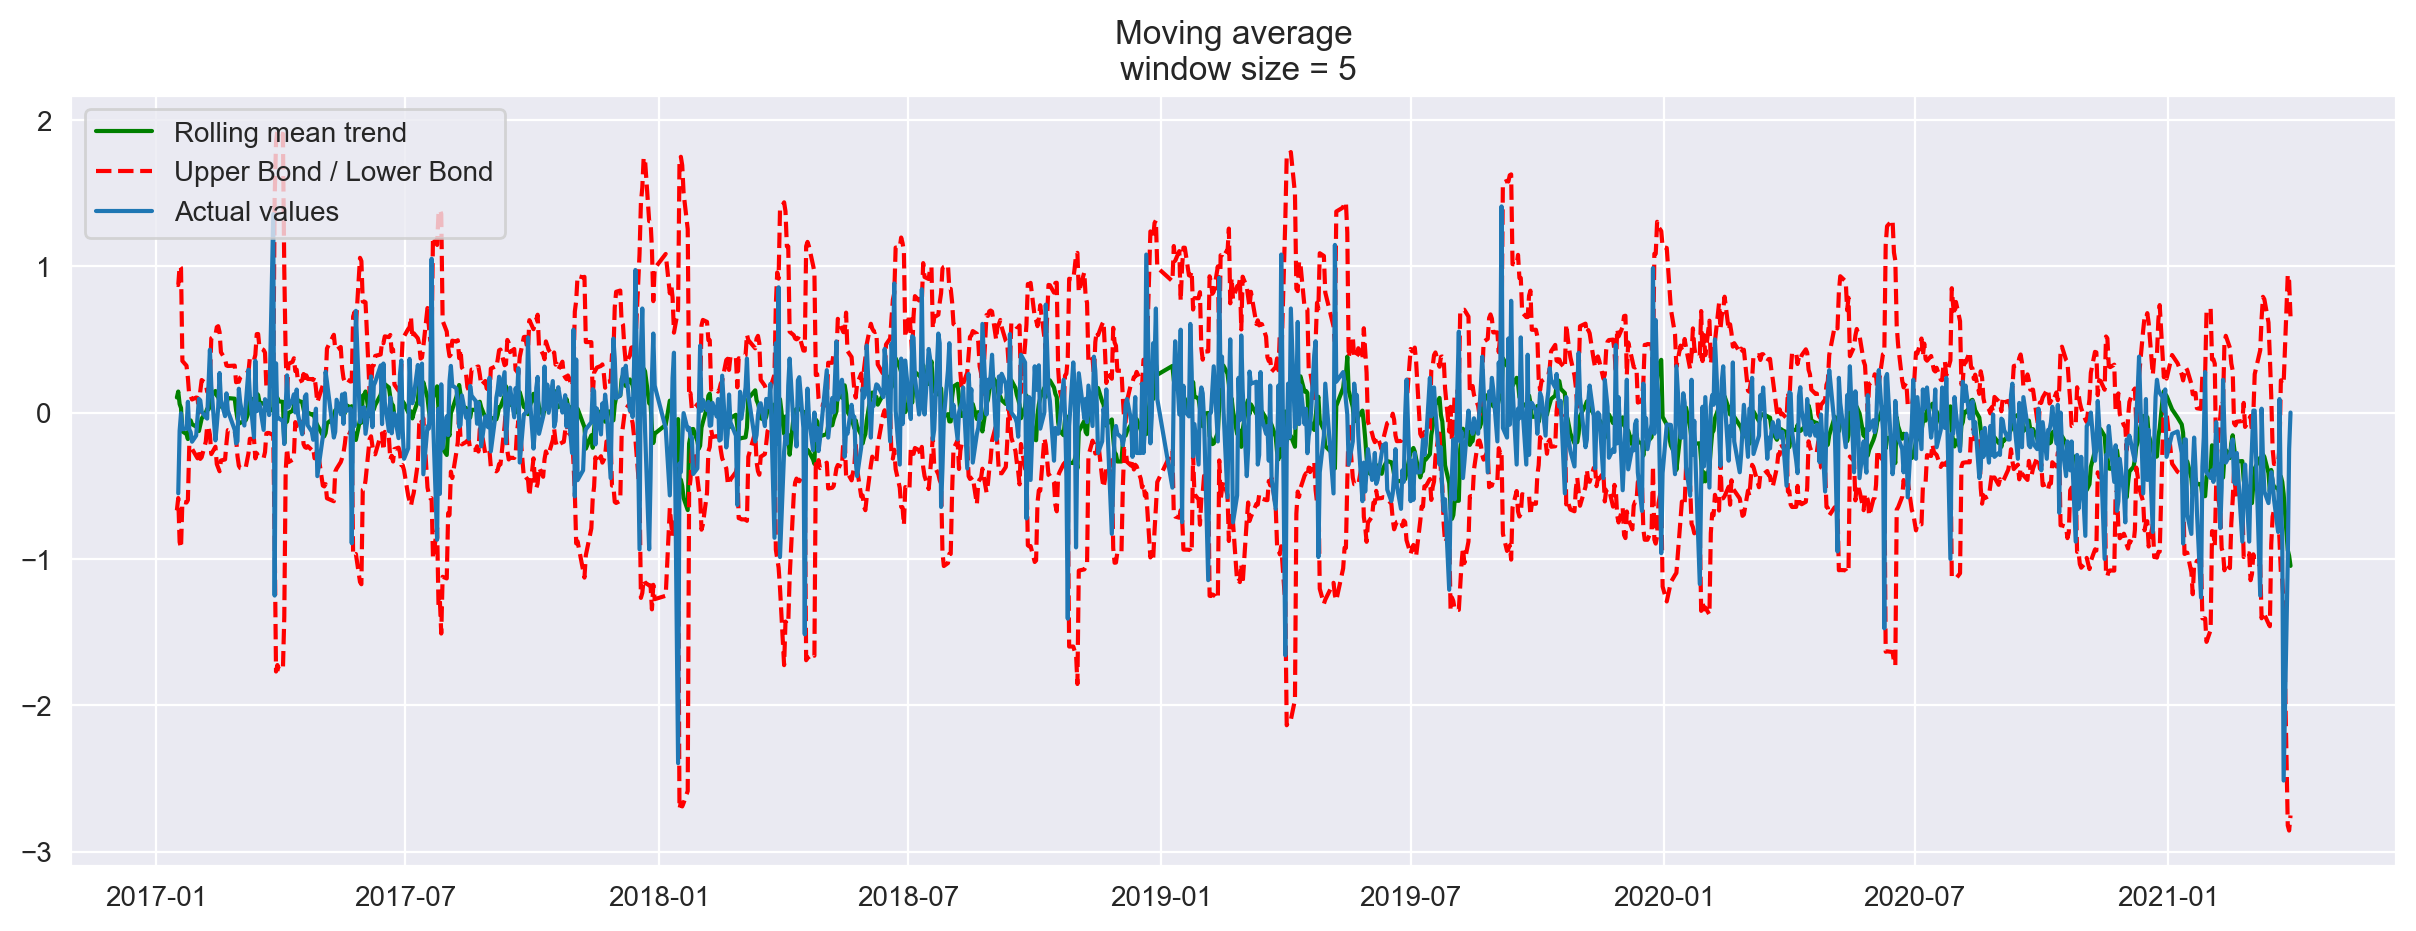

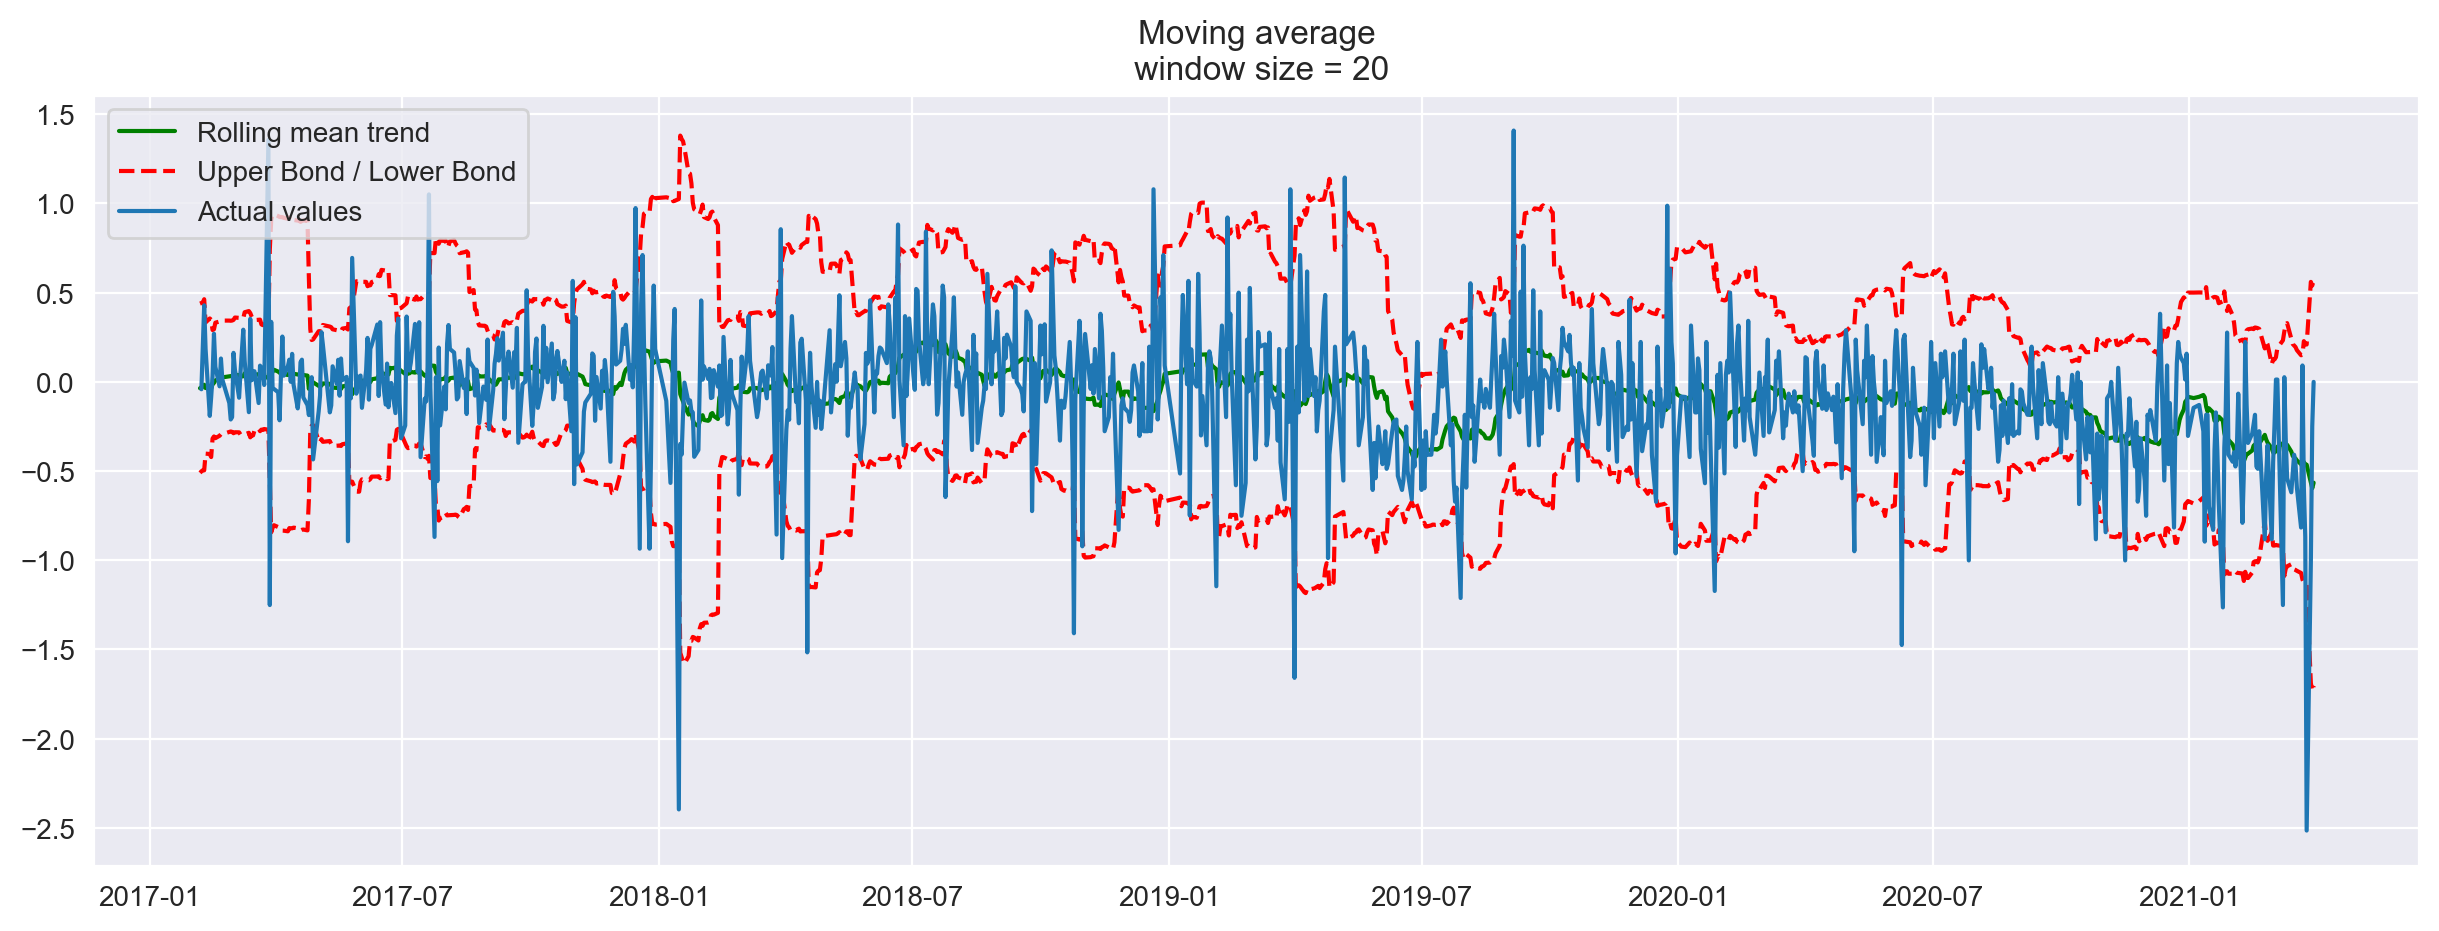

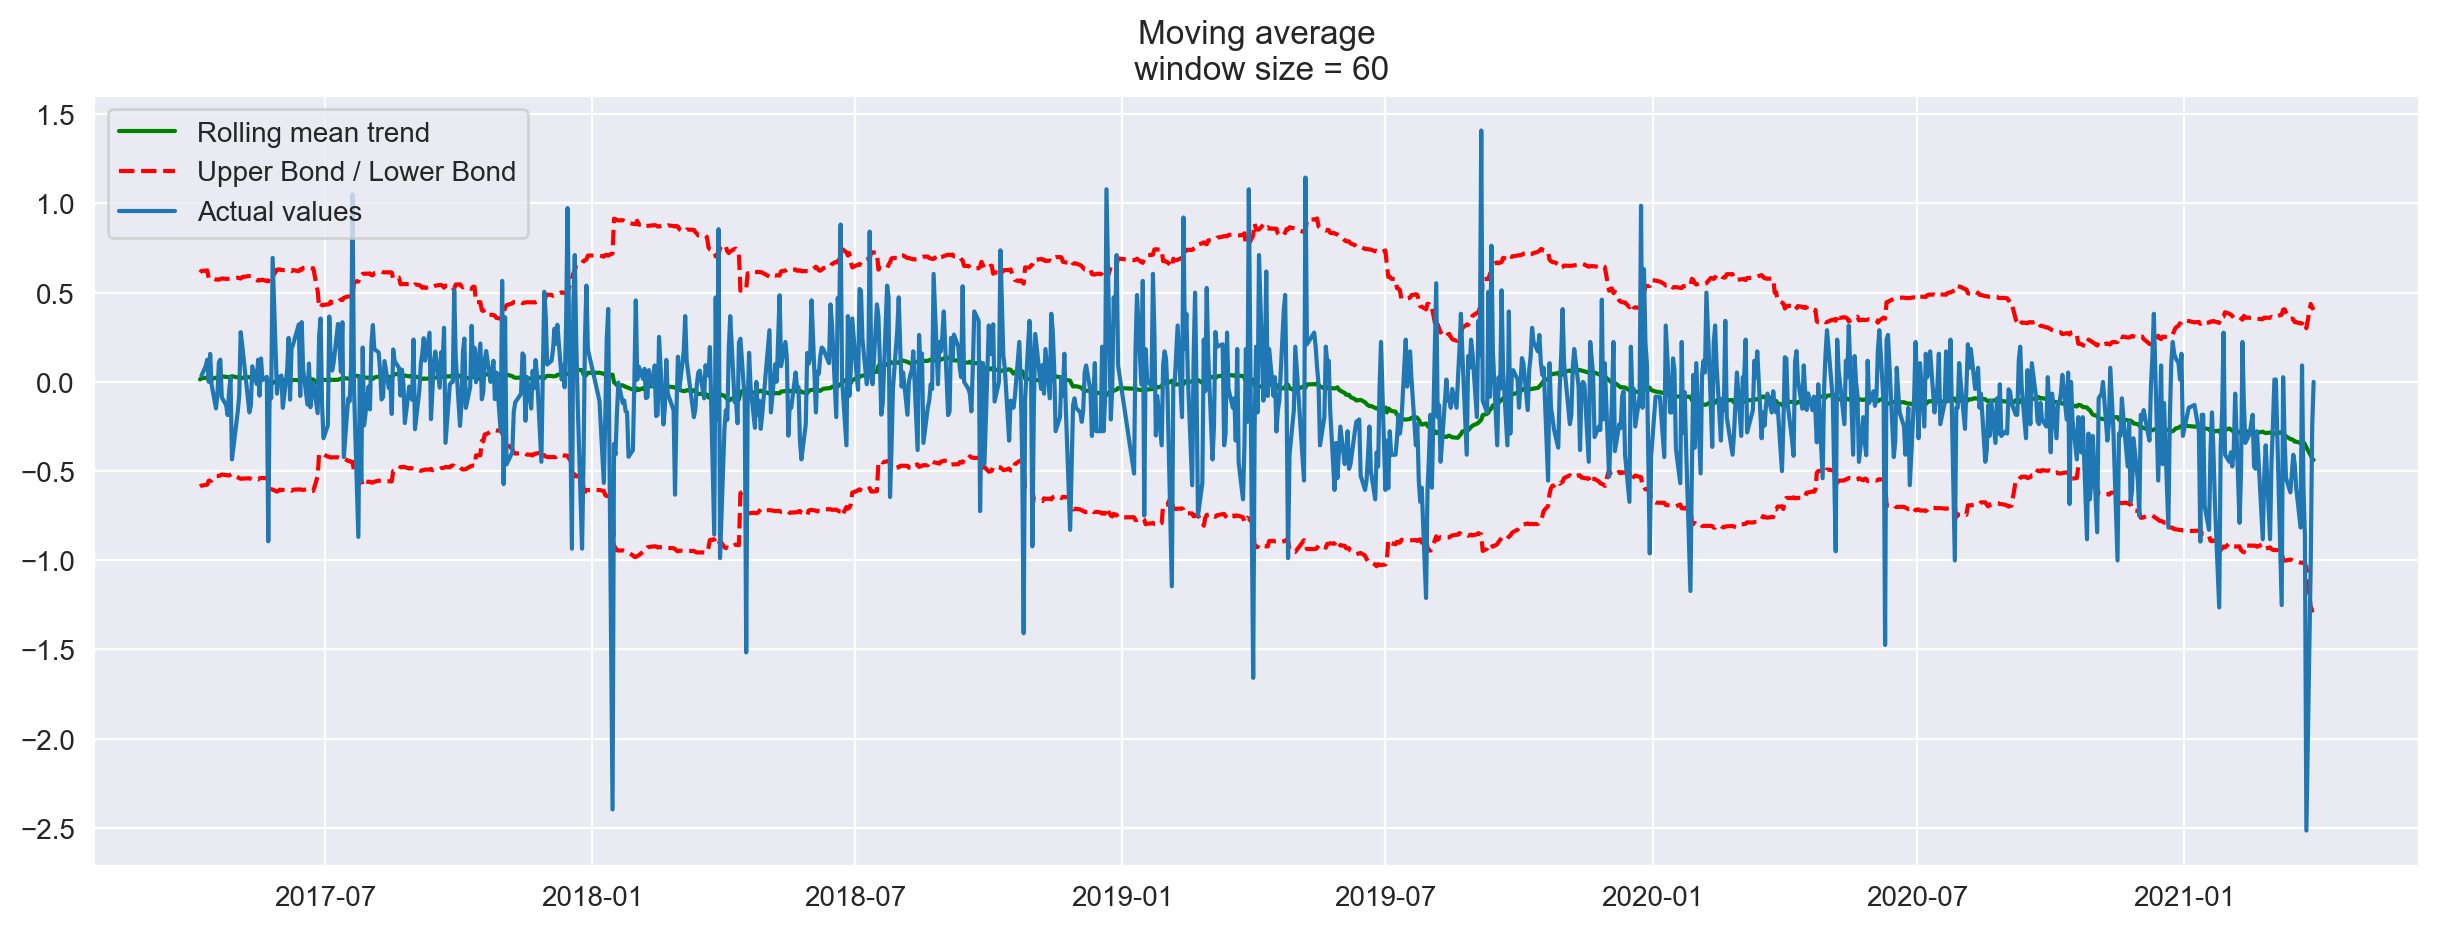

In [74]:
rolling_mean_5 = plotMovingAverage(dataset['Balance'], 5) 
rolling_mean_20 = plotMovingAverage(dataset['Balance'], 20)
rolling_mean_60 = plotMovingAverage(dataset['Balance'], 60)

In [75]:
pred_5 = rolling_mean_5[rolling_mean_5.index.year == 2021].to_numpy()
pred_20 = rolling_mean_20[rolling_mean_5.index.year == 2021].to_numpy()
pred_60 = rolling_mean_60[rolling_mean_5.index.year == 2021].to_numpy()

#### Экспоненциальное сглаживание

In [76]:
def exponential_smoothing(series, alpha):
    result = [series[0]]
    for n in range(1, len(series)-1):
        result.append(alpha * series[n] + (1 - alpha) * result[n-1])
    return [np.nan]+result

In [77]:
alpha1 = 0.6
alpha2 = 0.1
df = pd.concat([dataset['Balance'],
                pd.DataFrame(exponential_smoothing(dataset['Balance'], alpha1), index=dataset.index), 
                pd.DataFrame(exponential_smoothing(dataset['Balance'], alpha2), index=dataset.index)], axis=1)
df.columns=['Actual', 'Alpha = ' + str(alpha1), 'Alpha = ' + str(alpha2)]

In [78]:
plotly_df(df, title = "Exponential Smooting")

In [79]:
pred_exp_01 = df[df.index.year == 2021]['Alpha = 0.1']
pred_exp_06 = df[df.index.year == 2021]['Alpha = 0.6']

#### Двойное экспоненциальное сглаживание

In [80]:
def double_exponential_smoothing(series, alpha, beta):
    level, trend = series[0], 0
    result = [level + trend]
    for n in range(1, len(series)-1):
        last_level, level = level, alpha*series[n] + (1-alpha)*(level+trend)
        trend = beta*(level-last_level) + (1-beta)*trend
        result.append((level+trend))
    return [np.nan]+result

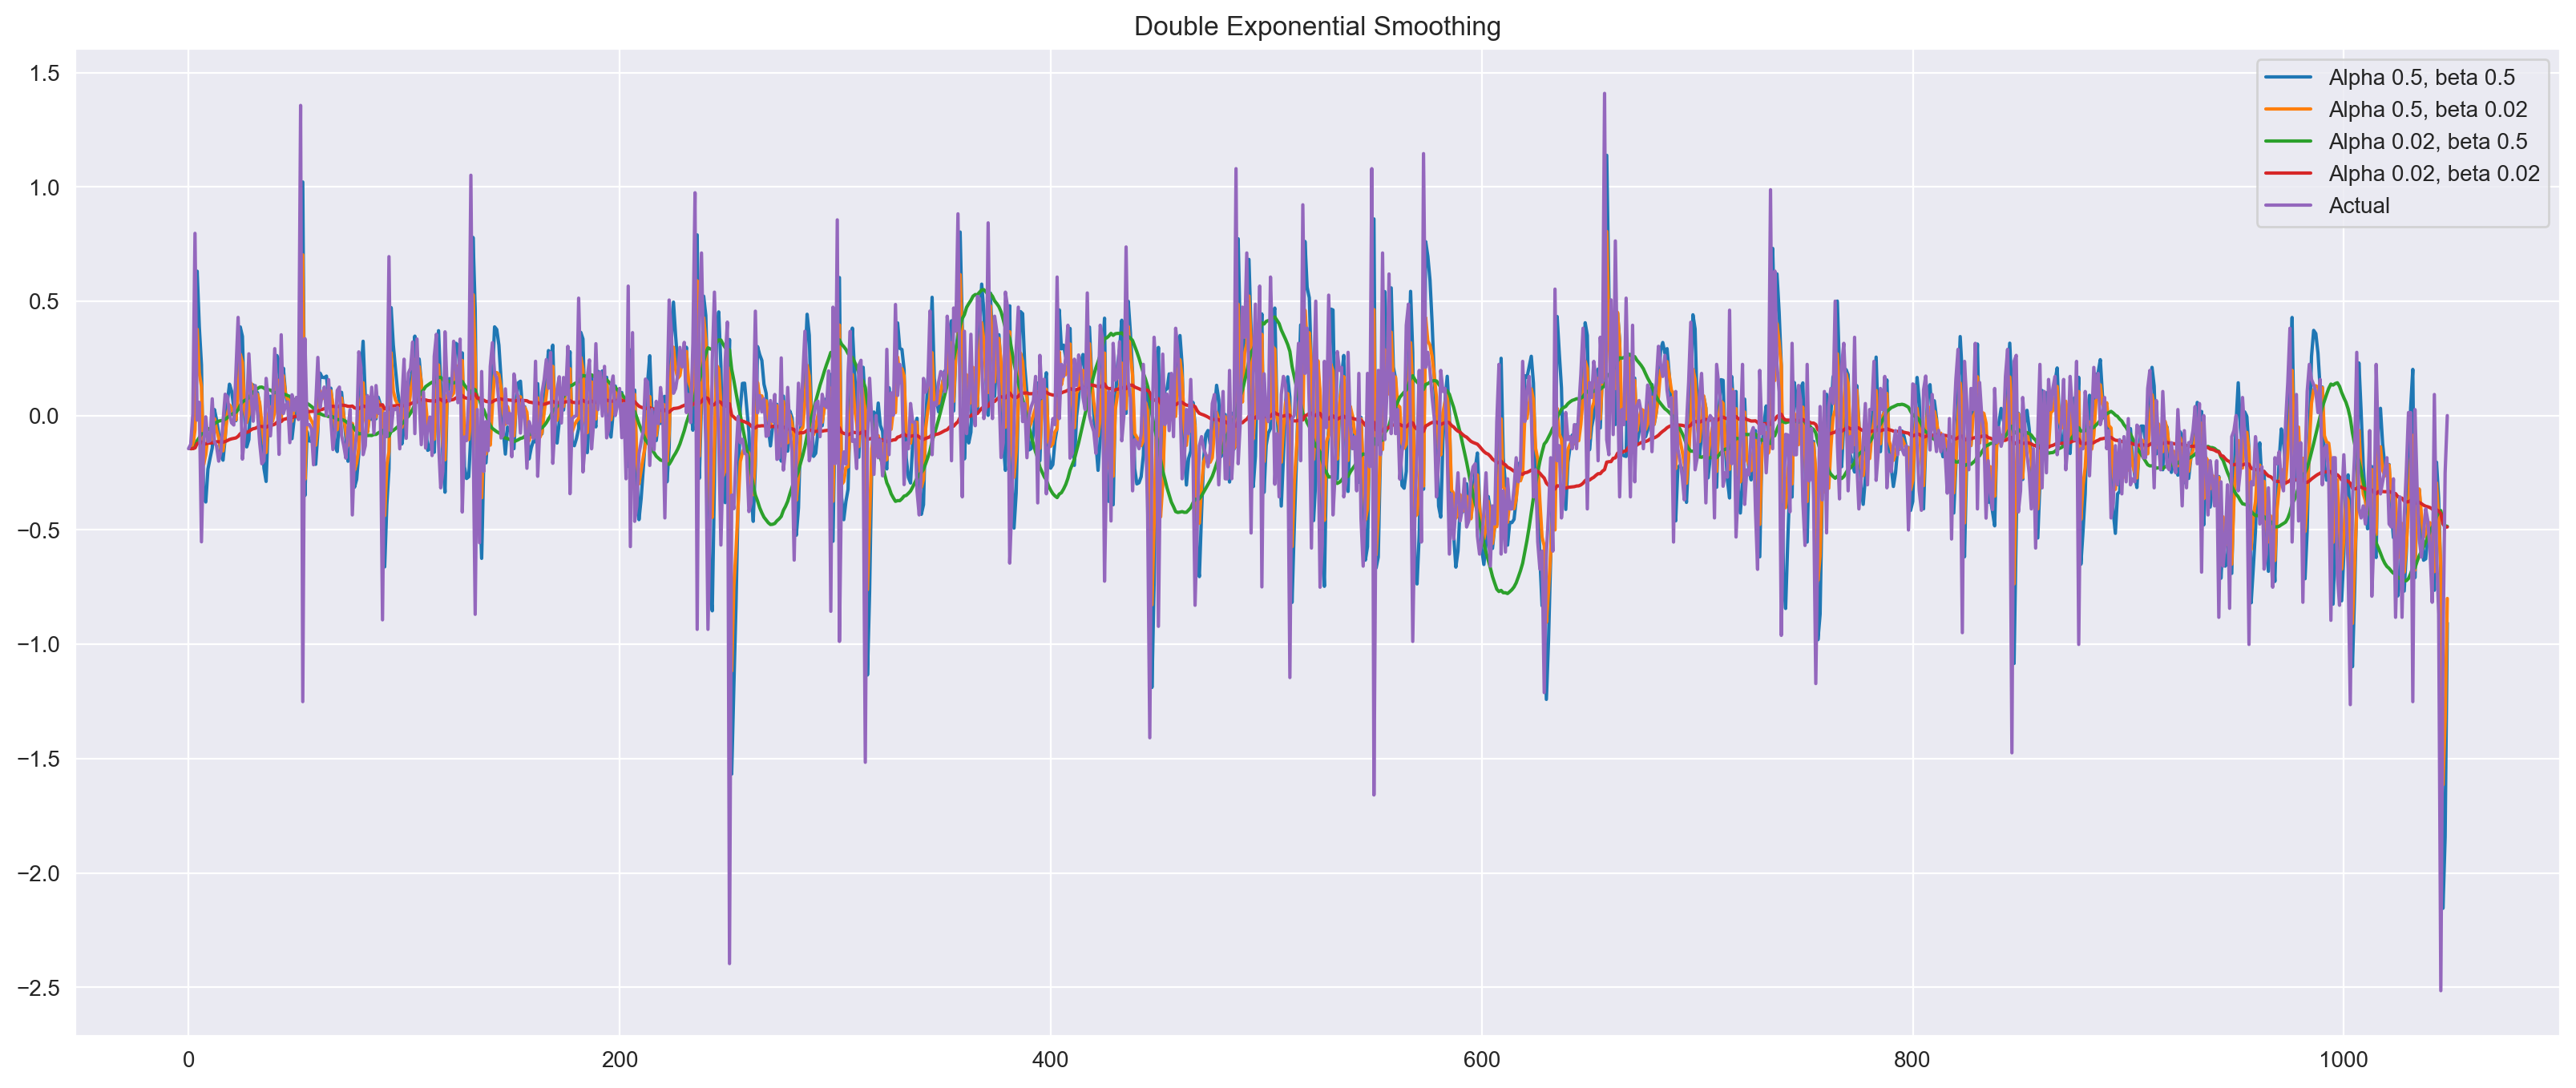

In [81]:
plt.figure(figsize=(20, 8))
for alpha in [0.5, 0.02]:
    for beta in [0.5, 0.02]:
        plt.plot(double_exponential_smoothing(dataset['Balance'], alpha, beta), label="Alpha {}, beta {}".format(alpha, beta))
plt.plot(dataset['Balance'].values, label = "Actual")
plt.legend(loc="best")
plt.axis('tight')
plt.title("Double Exponential Smoothing")
plt.grid(True)

#### Считаем ошибку

In [82]:
df = pd.concat([pd.DataFrame(dataset['Balance']),
                pd.DataFrame(exponential_smoothing(dataset['Balance'], 0.4), index=dataset.index),
                pd.DataFrame(double_exponential_smoothing(dataset['Balance'], 0.7, 0.4), index=dataset.index)], axis=1)
df.columns=['Actual', 'Smoothing', 'Double Smoothing']
plotly_df(df, title='Сравнение двух методов')

In [83]:
df

,Actual,Smoothing,Double Smoothing
Timestamp,,,
2017-01-09,-0.144836,NaN,NaN
2017-01-10,-0.125572,-0.144836,-0.144836
2017-01-11,0.007767,-0.137131,-0.125957
2017-01-12,0.796823,-0.079172,0.010486
2017-01-13,-0.019721,0.271226,0.823933
...,...,...,...
2021-03-25,-0.869018,-0.443703,-0.415959
2021-03-26,-2.514887,-0.613829,-0.854403
2021-03-29,-1.013855,-1.374252,-2.602980


In [84]:
df = pd.DataFrame({
    "double_smoth_07_04" : double_exponential_smoothing(dataset['Balance'], 0.7, 0.4),
    "double_smoth_04_07" : double_exponential_smoothing(dataset['Balance'], 0.4, 0.7)
}, index=dataset.index)

pred_double_smoth_07_04 = df[df.index.year == 2021]['double_smoth_07_04'].to_numpy()
pred_double_smoth_04_07 = df[df.index.year == 2021]['double_smoth_04_07'].to_numpy()

#### Тройное экспоненциальное сглаживание (известное также как модель Хольта-Винтерса)

In [85]:
class HoltWinters:
    
    """
    Модель Хольта-Винтерса с методом Брутлага для детектирования аномалий
    https://fedcsis.org/proceedings/2012/pliks/118.pdf
    
    
    # series - исходный временной ряд
    # slen - длина сезона
    # alpha, beta, gamma - коэффициенты модели Хольта-Винтерса
    # n_preds - горизонт предсказаний
    # scaling_factor - задаёт ширину доверительного интервала по Брутлагу (обычно принимает значения от 2 до 3)
    
    """
    
    
    def __init__(self, series, slen, alpha, beta, gamma, n_preds, scaling_factor=1.96):
        self.series = series
        self.slen = slen
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.n_preds = n_preds
        self.scaling_factor = scaling_factor
        
        
    def initial_trend(self):
        summ = 0.0
        for i in range(self.slen):
            summ += float(self.series[i+self.slen] - self.series[i]) / self.slen
        return summ / self.slen
    
    def initial_seasonal_components(self):
        seasonals = {}
        season_averages = []
        n_seasons = int(len(self.series)/self.slen)
        # вычисляем сезонные средние
        for j in range(n_seasons):
            season_averages.append(sum(self.series[self.slen*j:self.slen*j+self.slen])/float(self.slen))
        # вычисляем начальные значения
        for i in range(self.slen):
            sum_of_vals_over_avg = 0.0
            for j in range(n_seasons):
                sum_of_vals_over_avg += self.series[self.slen*j+i]-season_averages[j]
            seasonals[i] = sum_of_vals_over_avg/n_seasons
        return seasonals   

          
    def triple_exponential_smoothing(self):
        self.result = []
        self.Smooth = []
        self.Season = []
        self.Trend = []
        self.PredictedDeviation = []
        self.UpperBond = []
        self.LowerBond = []
        
        seasonals = self.initial_seasonal_components()
        
        for i in range(len(self.series)+self.n_preds):
            if i == 0: # инициализируем значения компонент
                smooth = self.series[0]
                trend = self.initial_trend()
                self.result.append(self.series[0])
                self.Smooth.append(smooth)
                self.Trend.append(trend)
                self.Season.append(seasonals[i%self.slen])
                
                self.PredictedDeviation.append(0)
                
                self.UpperBond.append(self.result[0] + 
                                      self.scaling_factor * 
                                      self.PredictedDeviation[0])
                
                
                self.LowerBond.append(self.result[0] - 
                                      self.scaling_factor * 
                                      self.PredictedDeviation[0])
                
                
                
                continue
            if i >= len(self.series): # прогнозируем
                m = i - len(self.series) + 1
                self.result.append((smooth + m*trend) + seasonals[i%self.slen])
                
                # во время прогноза с каждым шагом увеличиваем неопределенность
                self.PredictedDeviation.append(self.PredictedDeviation[-1]*1.01) 
                
            else:
                val = self.series[i]
                last_smooth, smooth = smooth, self.alpha*(val-seasonals[i%self.slen]) + (1-self.alpha)*(smooth+trend)
                trend = self.beta * (smooth-last_smooth) + (1-self.beta)*trend
                seasonals[i%self.slen] = self.gamma*(val-smooth) + (1-self.gamma)*seasonals[i%self.slen]
                self.result.append(smooth+trend+seasonals[i%self.slen])
                
                # Отклонение рассчитывается в соответствии с алгоритмом Брутлага
                self.PredictedDeviation.append(self.gamma * np.abs(self.series[i] - self.result[i]) 
                                               + (1-self.gamma)*self.PredictedDeviation[-1])
                
            
            self.UpperBond.append(self.result[-1] + 
                                  self.scaling_factor * 
                                  self.PredictedDeviation[-1])


            self.LowerBond.append(self.result[-1] - 
                                  self.scaling_factor * 
                                  self.PredictedDeviation[-1])
                
                
                
            
            self.Smooth.append(smooth)
            self.Trend.append(trend)
            self.Season.append(seasonals[i%self.slen])  

In [86]:
from sklearn.model_selection import TimeSeriesSplit
SLEN = 20

def timeseriesCVscore(x, data):
    # вектор ошибок
    errors = []
    
    values = data.values
    alpha, beta, gamma = x
    
    # задаём число фолдов для кросс-валидации
    tscv = TimeSeriesSplit(n_splits=3) 
    
    # идем по фолдам, на каждом обучаем модель, строим прогноз на отложенной выборке и считаем ошибку
    for train, test in tscv.split(values):

        model = HoltWinters(series=values[train], slen = SLEN, alpha=alpha, beta=beta, gamma=gamma, n_preds=len(test))
        model.triple_exponential_smoothing()
        
        predictions = model.result[-len(test):]
        actual = values[test]
        error = mean_squared_error(predictions, actual)
        errors.append(error)
    return np.mean(np.array(errors))

In [87]:
train = dataset[dataset.index.year < 2021]['Balance']
test = dataset[dataset.index.year >= 2021]['Balance']
len_train = len(train)

preds = []
for i in tqdm(range(5, len(test)+5, 5)):

    if i >= len(test):
        i = len(test)

    x = [0, 0, 0] 
    opt = minimize(timeseriesCVscore, x0=x, args=(train), method="TNC", bounds = ((0, 1), (0, 1), (0, 1)))
    alpha_final, beta_final, gamma_final = opt.x
    
    train = dataset.iloc[:len_train+i, 2]
    model = HoltWinters(train, slen = SLEN, alpha = alpha_final, beta = beta_final, gamma = gamma_final, n_preds = 1, scaling_factor = 2.56)
    model.triple_exponential_smoothing()

    idx = 5 if i % 5 == 0 else i % 5
    preds.extend(model.result[-idx:])

hw_pred = preds

100%|██████████| 12/12 [00:10<00:00,  1.15it/s]


In [88]:
train_data = dataset['Balance'].iloc[:250]
test_data = dataset['Balance'].iloc[250:]


x = [0, 0, 0] 
opt = minimize(timeseriesCVscore, x0=x, args=(train_data), method="TNC", bounds = ((0, 1), (0, 1), (0, 1)))

alpha_final, beta_final, gamma_final = opt.x
print(alpha_final, beta_final, gamma_final)

0.13953378517673415 0.026974773476505787 0.0


In [89]:
model = HoltWinters(test_data[:-1], slen = SLEN, alpha = alpha_final, beta = beta_final, gamma = gamma_final, n_preds = 1, scaling_factor = 2.56)
model.triple_exponential_smoothing()

In [90]:
df_holt = pd.concat([pd.DataFrame(test_data.values, index=test_data.index),
                     pd.DataFrame(model.result, index=test_data.index)], axis=1)
df_holt.columns=['Actual', 'HoltWinters']

In [91]:
plotly_df(df_holt, title='HoltWinters')

### Feature Exctractor

In [92]:
def code_mean(data, cat_feature, real_feature):
    """
    Возвращает словарь, где ключами являются уникальные категории признака cat_feature, 
    а значениями - средние по real_feature
    """
    return dict(data.groupby(cat_feature)[real_feature].mean())

In [93]:
dataset

,Income,Outcome,Balance
Timestamp,,,
2017-01-09,1.343028,1.487865,-0.144836
2017-01-10,1.068610,1.194182,-0.125572
2017-01-11,0.944429,0.936663,0.007767
2017-01-12,1.672202,0.875379,0.796823
2017-01-13,0.955924,0.975645,-0.019721
...,...,...,...
2021-03-25,2.304215,3.173234,-0.869018
2021-03-26,2.172546,4.687433,-2.514887
2021-03-29,2.356883,3.370738,-1.013855


In [94]:
df = pd.read_csv("../data/dataset.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.set_index('Timestamp')
dataset = df.copy()

In [95]:
dataset['month'] = dataset.index.month

lags = list(range(1, 2))
for l in lags:
    dataset[f'lag_income_{l}'] = dataset['Income'].shift(l)
    dataset[f'lag_outcome_{l}'] = dataset['Outcome'].shift(l)

windows = [3, 7, 14]
for window in windows:
    dataset[f'rolling_mean_{window}'] = dataset['Balance'].shift(1).rolling(window).mean()
    dataset[f'rolling_std_{window}'] = dataset['Balance'].shift(1).rolling(window).std()

dataset['rate_diff'] = dataset['rate_russ'] - dataset['rate_usa']

day_data = pd.get_dummies(dataset['week_day'], prefix='week_day').astype(int)
month_data = pd.get_dummies(dataset['month'], prefix='month').astype(int)

dataset = pd.concat([dataset, day_data, month_data], axis=1)

dataset = dataset.bfill()
dataset = dataset.drop(columns=['Date', 'week_day_name', 'is_holiday', "Income", "Outcome", 'target_inflation', 'real_inflation', 'rate_russ', 'rate_usa', 'week_day', 'month'], axis=1)

<Axes: >

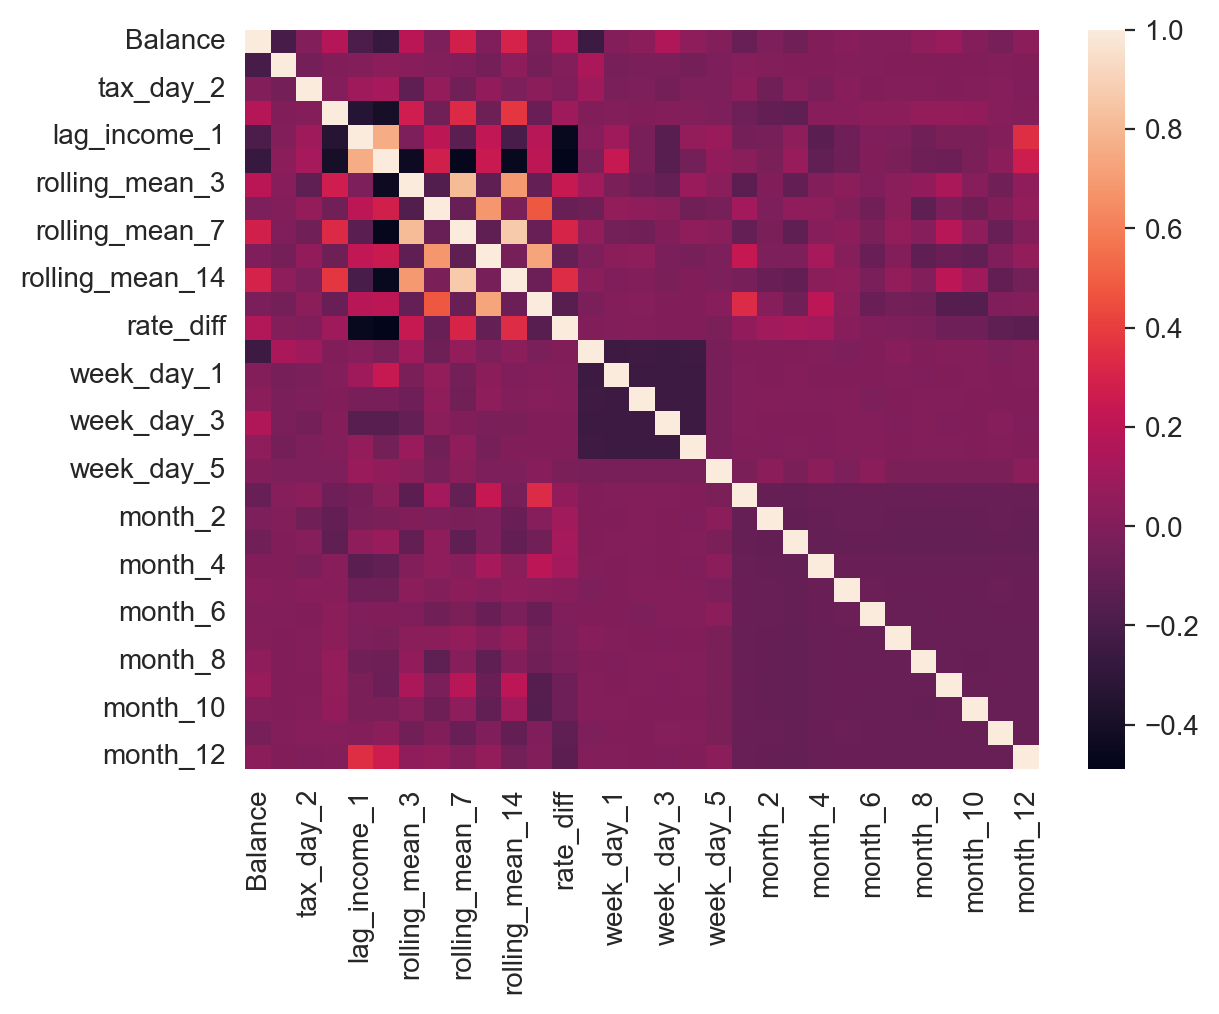

In [96]:
sns.heatmap(dataset.corr())

In [97]:
dataset

,Balance,tax_day_1,tax_day_2,real_target_diff,lag_income_1,lag_outcome_1,rolling_mean_3,rolling_std_3,rolling_mean_7,rolling_std_7,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
Timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-09,-0.144836,0,0,-0.6,1.343028,1.487865,-0.087547,0.083104,0.002918,0.404179,...,0,0,0,0,0,0,0,0,0,0
2017-01-10,-0.125572,0,0,-0.6,1.343028,1.487865,-0.087547,0.083104,0.002918,0.404179,...,0,0,0,0,0,0,0,0,0,0
2017-01-11,0.007767,0,0,-0.6,1.068610,1.194182,-0.087547,0.083104,0.002918,0.404179,...,0,0,0,0,0,0,0,0,0,0
2017-01-12,0.796823,0,0,-0.6,0.944429,0.936663,-0.087547,0.083104,0.002918,0.404179,...,0,0,0,0,0,0,0,0,0,0
2017-01-13,-0.019721,0,0,-0.6,1.672202,0.875379,0.226339,0.498532,0.002918,0.404179,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-25,-0.869018,1,0,-1.5,1.935541,2.528054,-0.438898,0.473339,-0.470248,0.280419,...,1,0,0,0,0,0,0,0,0,0
2021-03-26,-2.514887,0,0,-1.5,2.304215,3.173234,-0.456454,0.494827,-0.521035,0.319087,...,1,0,0,0,0,0,0,0,0,0
2021-03-29,-1.013855,0,1,-1.5,2.172546,4.687433,-1.325473,1.039299,-0.821994,0.810306,...,1,0,0,0,0,0,0,0,0,0


In [98]:
features = dataset.drop(columns=['Balance'], axis=1)
target = dataset['Balance']

y_test = target[target.index.year == 2021]

### Линейная модель

In [99]:
from sklearn.linear_model import LinearRegression

train = features[target.index.year < 2021].index
len_train = len(train)

X_train = features.iloc[:len_train,:]
y_train = target.iloc[:len_train]

preds = []
for i in tqdm(range(5, len(test)+5, 5)):

    if i >= len(test):
        i = len(test)

    model = LinearRegression()
    model.fit(X_train, y_train)
    prediction = model.predict(X_train)

    X_train = features.iloc[:len_train+i,:]
    y_train = target.iloc[:len_train+i]
    
    prediction = model.predict(X_train)

    idx = 5 if i % 5 == 0 else i % 5
    preds.extend(prediction[-idx:])

lin_pred = preds

100%|██████████| 12/12 [00:00<00:00, 266.33it/s]


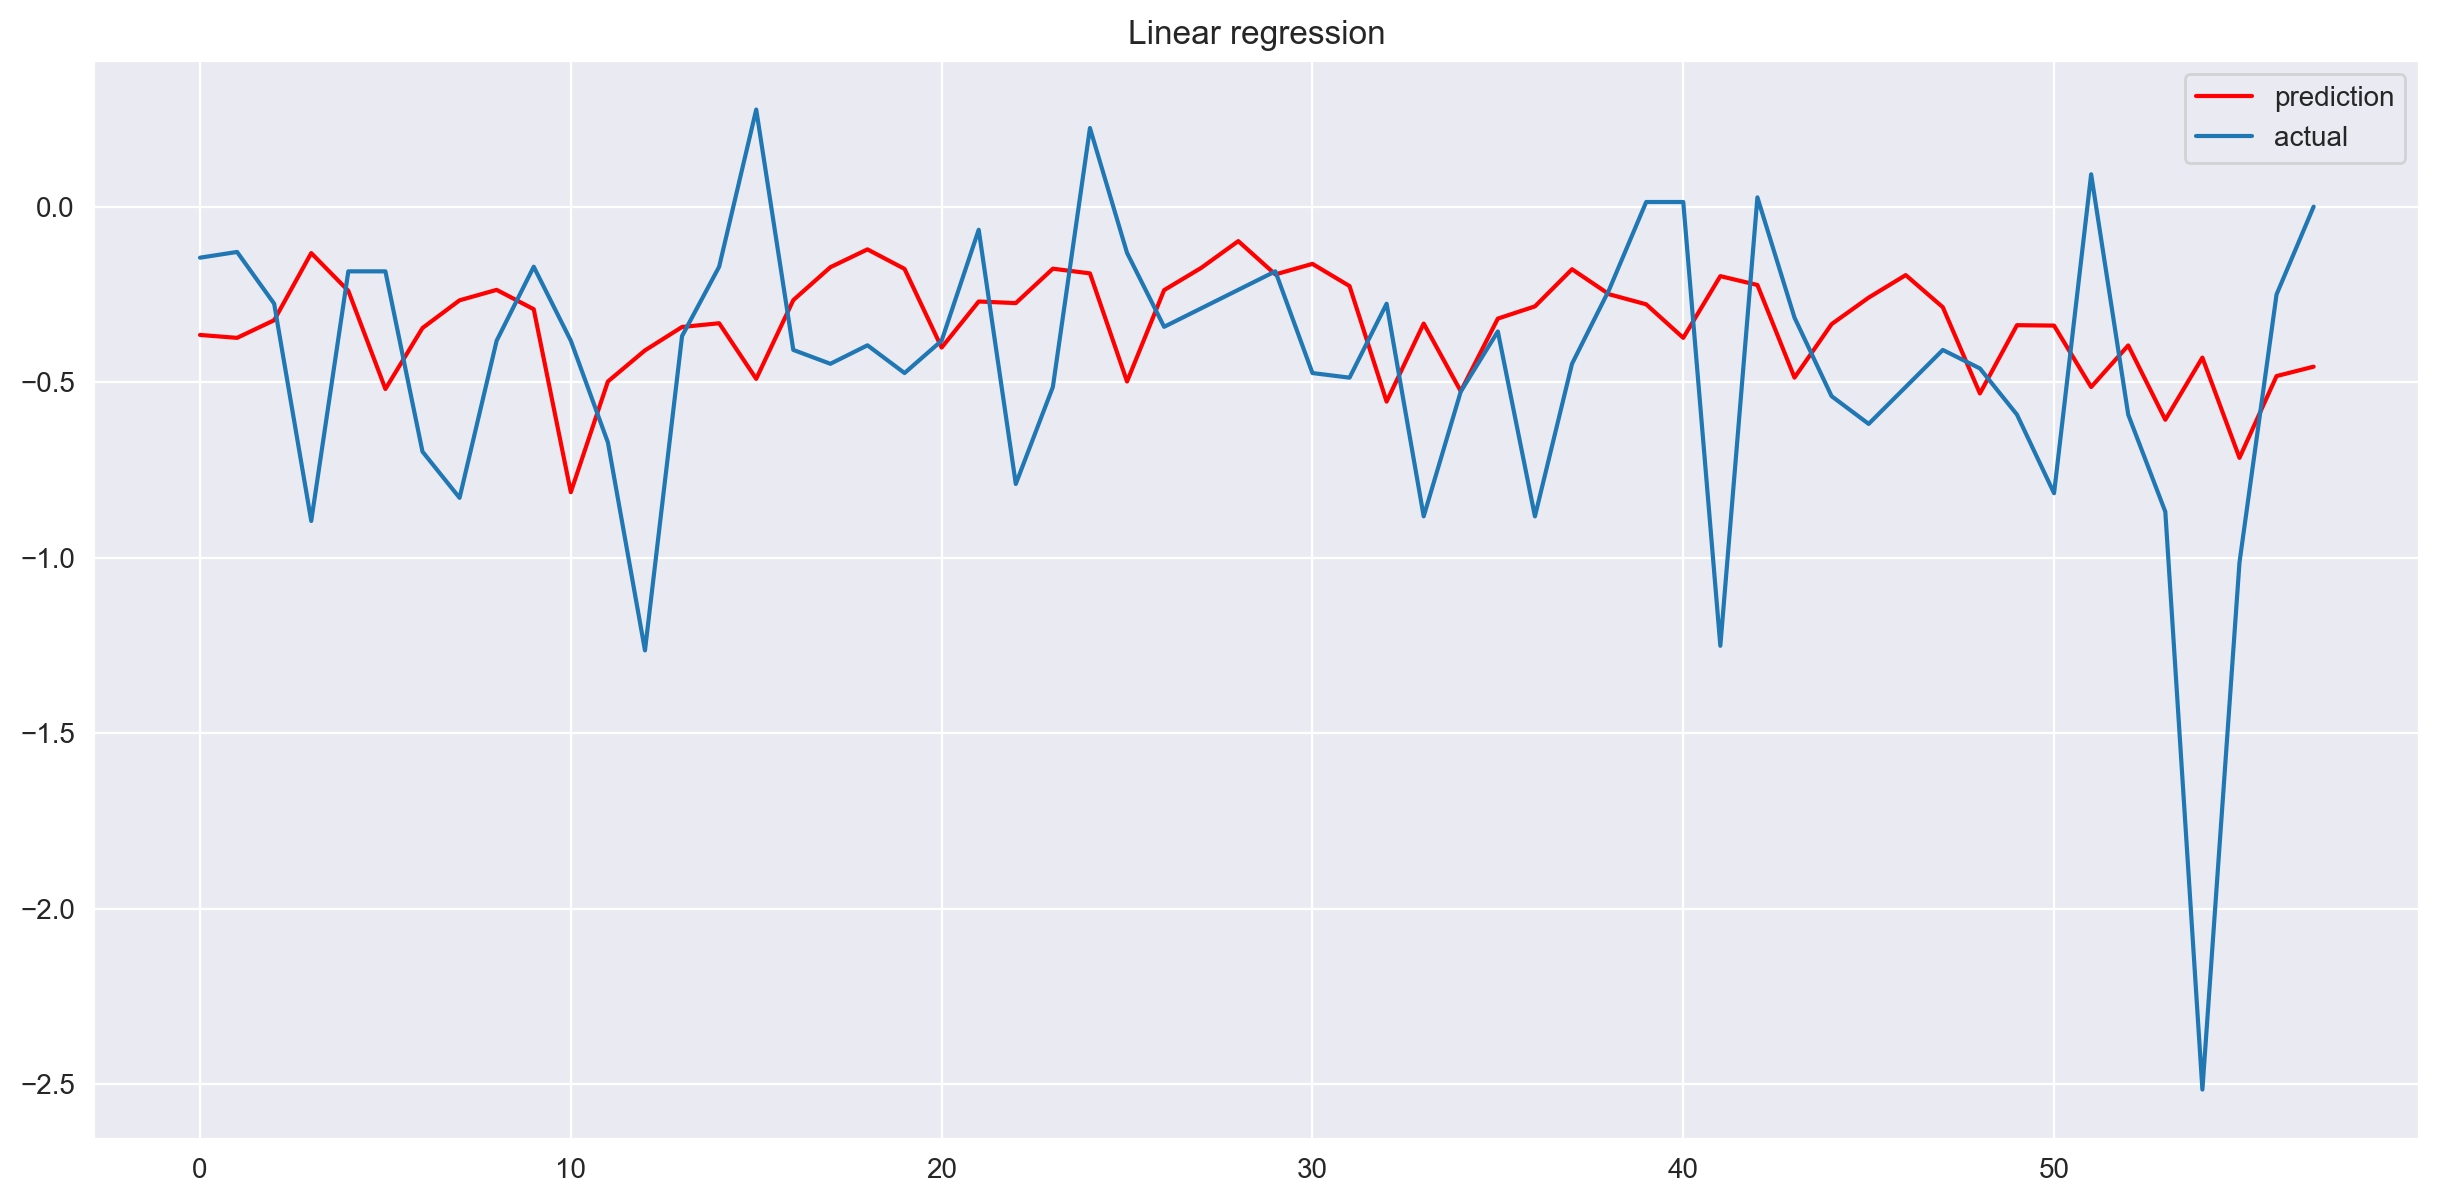

In [100]:
plt.figure(figsize=(15, 7))
plt.plot(lin_pred, "r", label="prediction")
plt.plot(y_true, label="actual")
plt.legend(loc="best")
plt.title("Linear regression")
plt.grid(True)

### Бустинг

In [101]:
from catboost import CatBoostRegressor, Pool

train = features[target.index.year < 2021].index
len_train = len(train)

X_train = features.iloc[:len_train,:]
y_train = target.iloc[:len_train]
train_pool = Pool(X_train, y_train)

preds = []
for i in tqdm(range(5, len(test)+5, 5)):

    if i >= len(test):
        i = len(test)

    model = CatBoostRegressor(iterations=2000, depth=3)
    model.fit(train_pool, verbose=False)

    X_train = features.iloc[:len_train+i,:]
    y_train = target.iloc[:len_train+i]
    train_pool = Pool(X_train, y_train)
    prediction = model.predict(train_pool)

    idx = 5 if i % 5 == 0 else i % 5
    preds.extend(prediction[-idx:])

boost_pred = preds

100%|██████████| 12/12 [00:04<00:00,  2.91it/s]


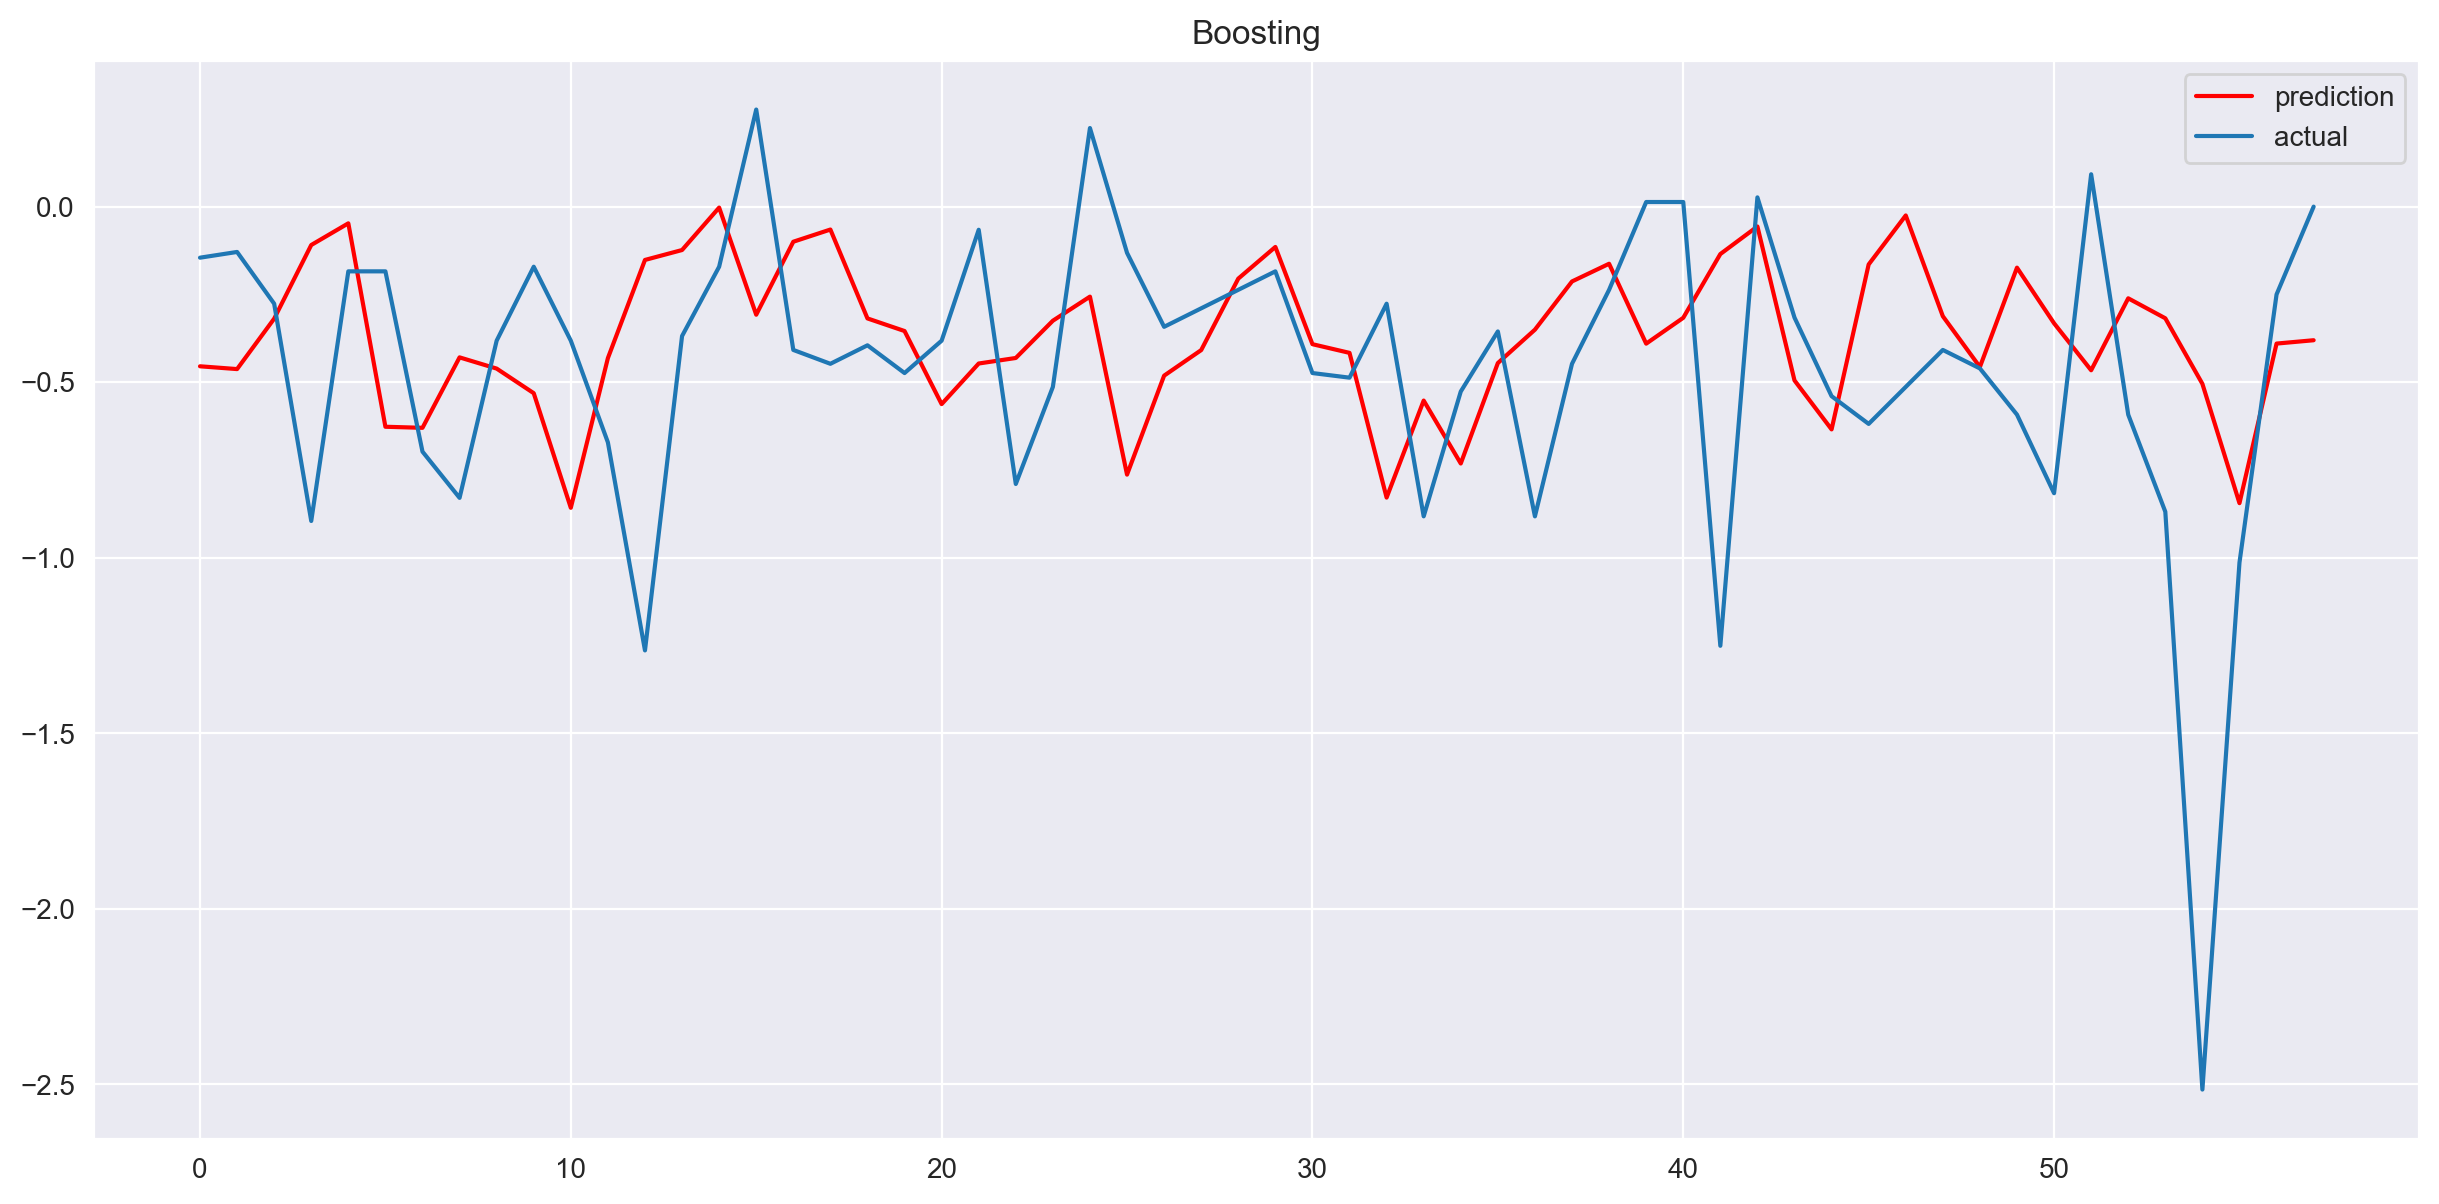

In [126]:
plt.figure(figsize=(15, 7))
plt.plot(boost_pred, "r", label="prediction")
plt.plot(y_true, label="actual")
plt.legend(loc="best")
plt.title("Boosting")
plt.grid(True)

### Результаты

In [111]:
from metric import FinEffect
eff = FinEffect()

In [112]:
print(f"В тестовом периоде: {len(y_true)} наблюдений")

В тестовом периоде: 58 наблюдений


In [120]:
def calc_metrics(y_true, y_pred):
    mae = mean_squared_error(y_true, y_pred)
    value = round(eff.model_effct(y_pred, y_true) * 100, 10)
    strike_share = np.sum(np.abs(y_true - y_pred) >= 0.42) / len(y_true)
    return mae, value, strike_share

In [121]:
df = pd.DataFrame(columns=['MAE', "FinEff", "Strikes_share"])

In [122]:
df.loc['window_5'] = calc_metrics(y_true, pred_5)
df.loc['window_20'] = calc_metrics(y_true, pred_20) 
df.loc['window_60'] = calc_metrics(y_true, pred_60) 
df.loc['double_smoth_07_04'] = calc_metrics(y_true, pred_double_smoth_07_04) 
df.loc['double_smoth_04_07'] = calc_metrics(y_true, pred_double_smoth_04_07) 
df.loc['HoltWin'] = calc_metrics(y_true, hw_pred)
df.loc['Linear'] = calc_metrics(y_true, lin_pred)
df.loc['Boost'] = calc_metrics(y_true, boost_pred)

In [123]:
df

,MAE,FinEff,Strikes_share
window_5,0.207535,-0.000030,0.206897
window_20,0.201464,0.000000,0.258621
window_60,0.199739,0.000000,0.275862
double_smoth_07_04,0.336850,-0.001184,0.362069
double_smoth_04_07,0.333484,-0.000707,0.362069
HoltWin,0.203968,0.000000,0.241379
Linear,0.207642,0.000000,0.224138
Boost,0.220196,0.000000,0.275862


__Выыоды__:

Среди бейздайнов лучше всего себя HoltWin и Linear модел с точки зрения MAE. 
Однако самая маленькая доля пробоев у скользящего окна